<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/Network_Intrusion_Detection_using_Anomaly_Detection_Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Network Intrusion Detection using Anomaly Detection**

**Import Libraries**

In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest


import matplotlib.pyplot as plt
import seaborn as sns


DataSet

In [39]:
network_data = {
    "Packets":[120,140,160,180,220,150,130,170,145,3000,2800,3500],
    "Connections":[10,12,9,11,15,8,10,13,9,120,150,180]
}

df = pd.DataFrame(network_data)
print(df)

    Packets  Connections
0       120           10
1       140           12
2       160            9
3       180           11
4       220           15
5       150            8
6       130           10
7       170           13
8       145            9
9      3000          120
10     2800          150
11     3500          180


**Exploration Analysis**

**Calculation**

In [40]:
avg_packets = df["Packets"].mean()
max_packets = df["Packets"].max()
avg_connections = df["Connections"].mean()

print("\nTraffic Statistics")
print("Average Packets =", avg_packets)
print("Maximum Packets =", max_packets)
print("Average Connections =", avg_connections)


Traffic Statistics
Average Packets = 892.9166666666666
Maximum Packets = 3500
Average Connections = 45.583333333333336


**Visualize**

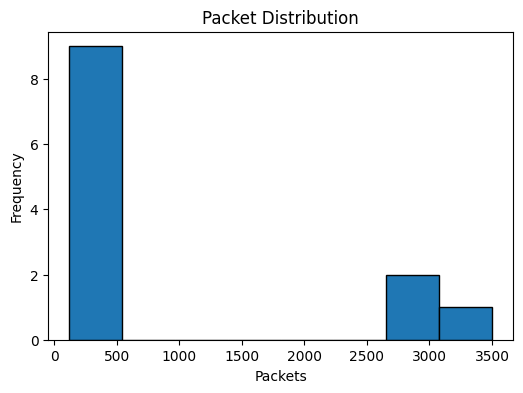

In [41]:
# Packet Distribution
plt.figure(figsize=(6,4))
plt.hist(df["Packets"], bins=8, edgecolor='black')
plt.xlabel("Packets")
plt.ylabel("Frequency")
plt.title("Packet Distribution")
plt.show()


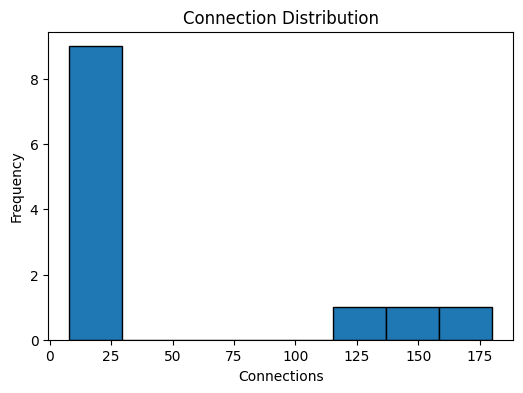

In [42]:
# Connection Distribution
plt.figure(figsize=(6,4))
plt.hist(df["Connections"], bins=8, edgecolor='black')
plt.xlabel("Connections")
plt.ylabel("Frequency")
plt.title("Connection Distribution")
plt.show()

**Anomaly Detection**

**Build an anomaly detection model.**

In [43]:
model = IsolationForest(
    contamination=0.25,
    random_state=42
  )

# Select only numerical features for the model
features = df[["Packets", "Connections"]]

df["Anomaly"] = model.fit_predict(features)

print("\nAnomaly Detection Results")
print(df)

# Convert labels to text
df["Status"] = df["Anomaly"].map({1:"Normal", -1:"Suspicious"})

print("\nUpdated Dataset")
print(df)


Anomaly Detection Results
    Packets  Connections  Anomaly
0       120           10        1
1       140           12        1
2       160            9        1
3       180           11        1
4       220           15        1
5       150            8        1
6       130           10        1
7       170           13        1
8       145            9        1
9      3000          120       -1
10     2800          150       -1
11     3500          180       -1

Updated Dataset
    Packets  Connections  Anomaly      Status
0       120           10        1      Normal
1       140           12        1      Normal
2       160            9        1      Normal
3       180           11        1      Normal
4       220           15        1      Normal
5       150            8        1      Normal
6       130           10        1      Normal
7       170           13        1      Normal
8       145            9        1      Normal
9      3000          120       -1  Suspicious
10     2

**Investigation**

In [44]:
#  Suspicious Records
suspicious_records = df[df["Anomaly"]==-1]

print("\nSuspicious Records")
print(suspicious_records)

# Potential DDoS Indicators
ddos = suspicious_records[suspicious_records["Packets"]>1000]

print("\nPotential DDoS Indicators")
print(ddos)

# High-Risk Network Events
print("\nHigh-Risk Network Events")
for index,row in ddos.iterrows():
    print("Packets:",row["Packets"]," Connections:",row["Connections"])


Suspicious Records
    Packets  Connections  Anomaly      Status
9      3000          120       -1  Suspicious
10     2800          150       -1  Suspicious
11     3500          180       -1  Suspicious

Potential DDoS Indicators
    Packets  Connections  Anomaly      Status
9      3000          120       -1  Suspicious
10     2800          150       -1  Suspicious
11     3500          180       -1  Suspicious

High-Risk Network Events
Packets: 3000  Connections: 120
Packets: 2800  Connections: 150
Packets: 3500  Connections: 180


**Report**

In [45]:
normal_records = len(df[df["Anomaly"]==1])
suspicious_count = len(df[df["Anomaly"]==-1])

anomaly_percentage = (suspicious_count/len(df))*100

print("\nNetwork Summary")
print("Normal Records =", normal_records)
print("Suspicious Records =", suspicious_count)
print("Percentage of Anomalies = {:.2f}%".format(anomaly_percentage))


Network Summary
Normal Records = 9
Suspicious Records = 3
Percentage of Anomalies = 25.00%


# **Network Intrusion Analysis Report**

**1. Dataset Overview**

The dataset contains 12 records with packet counts and network connections. Most values are normal, while a few records show unusually high traffic.

**2. Traffic Statistics**

* Average Packets: **892.916**
* Maximum Packets: **3500**
* Average Connections: **45.58**

**3. Anomaly Detection Results**

Isolation Forest detected:

* **Normal Records:** 9
* **Suspicious Records:** 3
* **Anomaly Percentage:** 25%

**4. Suspicious Network Activities**

Records with packet counts of **3000, 2800, and 3500** and high connection values were identified as suspicious and may indicate DDoS attacks.

**5. Security Recommendations**

* Monitor network traffic continuously.
* Enable IDS/IPS and firewall protection.
* Block malicious IP addresses.
* Implement DDoS mitigation techniques.


**6. Conclusion**

The anomaly detection model successfully identified three abnormal network events. Continuous monitoring and preventive security measures are necessary to protect the network from potential attacks.